# Анализ и визуализация результатов финального Fine-tuning на Benchmark-выборке: 4 стратегии и Scratch

### Импорты и базовые настройки

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [30]:
COLORS = {
    "scratch": "black",
    "partial_ft": "pink",
    "warmup": "purple",
    "full_ft": "blue",
    "low_lr_encoder": "red"
}

STRATEGY_RU = {
    "scratch": "Обучение с нуля",
    "full_ft": "Полный fine-tuning",
    "low_lr_encoder": "Замедленное дообучение энкодера",
    "partial_ft": "Частичный fine-tuning",
    "warmup": "Двухэтапное дообучение энкодера",
}

STRATEGY_ORDER = [
    "scratch",
    "full_ft",
    "low_lr_encoder",
    "partial_ft",
    "warmup",
]

### Пути

In [3]:
# === INPUT PATHS ===
ROOT = Path(r'C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Fine-tuning_FULLTest')
FT_CSV = ROOT / 'FT_strategies_summary.csv'
SCRATCH_CSV = ROOT / 'Scratch_summary.csv'

# === OUTPUT DIRS ===
OUT_DIR = Path("analysis_outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FT_CSV exists:", FT_CSV.exists(), FT_CSV)
print("SCRATCH_CSV exists:", SCRATCH_CSV.exists(), SCRATCH_CSV)
print("Output dir:", OUT_DIR.resolve())

FT_CSV exists: True C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Fine-tuning_FULLTest\FT_strategies_summary.csv
SCRATCH_CSV exists: True C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Fine-tuning_FULLTest\Scratch_summary.csv
Output dir: C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Fine-tuning_FULLTest\analysis_outputs


### Загрузка файлов

In [4]:
df_ft = pd.read_csv(FT_CSV)
df_scratch = pd.read_csv(SCRATCH_CSV)

print("df_ft shape:", df_ft.shape)
print("df_scratch shape:", df_scratch.shape)

display(df_ft.head())
display(df_scratch.head())

df_ft shape: (1464, 28)
df_scratch shape: (366, 33)


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr
0,subj_051,benchmark,0,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.5,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.534952,0.117603,0.210456,0.117603,1.000000,0.017394
1,subj_051,benchmark,0,ssl_ft,low_lr_encoder,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.5,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.534952,0.117603,0.210456,0.117603,1.000000,0.017394
2,subj_051,benchmark,0,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.5,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.534952,0.117603,0.210456,0.117603,1.000000,0.017394
3,subj_051,benchmark,0,ssl_ft,warmup,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,3.0,0.5,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.534952,0.117603,0.210456,0.117603,1.000000,0.017394
4,subj_051,benchmark,10,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.4,0.222222,623,125,2670,74,15,314,5.0,0.671958,15.0,0.508474,0.167790,0.212057,0.119314,0.952229,0.004054


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
0,subj_051,benchmark,0,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.50,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.499638,0.882397,0.000000,0.000000,0.000000,0.006737,benchmark__subj_051__p0__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
1,subj_051,benchmark,10,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.40,0.254545,623,125,2670,74,15,314,6.0,0.674627,16.0,0.550267,0.330337,0.217163,0.125888,0.789809,0.021560,benchmark__subj_051__p10__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
2,subj_051,benchmark,20,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.39,0.240964,1246,250,2670,148,30,314,3.0,0.686443,13.0,0.547048,0.245693,0.213281,0.121549,0.869427,0.018001,benchmark__subj_051__p20__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
3,subj_051,benchmark,40,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.40,0.233010,2492,499,2670,296,59,314,2.0,0.693760,12.0,0.563142,0.351685,0.213539,0.124536,0.748408,0.032400,benchmark__subj_051__p40__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
4,subj_051,benchmark,60,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.05,0.212664,3738,748,2670,444,89,314,1.0,0.704080,11.0,0.551749,0.117603,0.210456,0.117603,1.000000,0.008633,benchmark__subj_051__p60__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN


In [4]:
print("FT columns:")
print(df_ft.columns.tolist())

print("\nScratch columns:")
print(df_scratch.columns.tolist())

FT columns:
['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr']

Scratch columns:
['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr', 'run_tag', 'history_path', 'predictions_path', 'status', 'error']


### Приведение с единому формату и Объединение таблиц (только нужные признаки)

In [6]:
# --- копии ---
df_ft = df_ft.copy()
df_scratch = df_scratch.copy()

# --- создаём strategy ---
df_ft["strategy"] = df_ft["ft_strategy"].astype(str)
df_scratch["strategy"] = "scratch"

# --- приводим p ---
df_ft["p"] = df_ft["p"].astype(int)
df_scratch["p"] = df_scratch["p"].astype(int)

# --- оставляем только нужные колонки ---
core_cols = [
    "subject_id",
    "p",
    "strategy",
    "auc",
    "f1",
    "accuracy",
    "precision",
    "recall",
    "fdr"
]

optional_cols = ["group"]  # можно убрать, если не нужен

keep_cols = core_cols + optional_cols

df_ft = df_ft[keep_cols]
df_scratch = df_scratch[keep_cols]

# --- объединяем ---
df_all = pd.concat([df_ft, df_scratch], ignore_index=True)

print("df_all shape:", df_all.shape)
display(df_all.head())

df_all shape: (1830, 10)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group
0,subj_051,0,full_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark
1,subj_051,0,low_lr_encoder,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark
2,subj_051,0,partial_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark
3,subj_051,0,warmup,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark
4,subj_051,10,full_ft,0.508474,0.212057,0.167790,0.119314,0.952229,0.004054,benchmark


#### Проверка базовых значений

In [7]:
print("Unique strategies:", sorted(df_all["strategy"].dropna().unique().tolist()))
print("Unique p:", sorted(df_all["p"].dropna().unique().tolist()))
print("Number of subjects:", df_all["subject_id"].nunique())

Unique strategies: ['full_ft', 'low_lr_encoder', 'partial_ft', 'scratch', 'warmup']
Unique p: [0, 10, 20, 40, 60, 100]
Number of subjects: 61


#### Проверка ключевых метрик и обязательных колонок

In [8]:
required_cols = [
    "subject_id", "p", "strategy",
    "auc", "f1", "accuracy", "precision", "recall", "fdr"
]

missing_required = [c for c in required_cols if c not in df_all.columns]
print("Missing required columns:", missing_required)

Missing required columns: []


#### Проверка дубликатов по ключу subject_id × p × strategy

In [9]:
key_cols = ["subject_id", "p", "strategy"]

dup_mask = df_all.duplicated(subset=key_cols, keep=False)
df_dups = df_all.loc[dup_mask].sort_values(key_cols)

print("Number of duplicated rows by key:", len(df_dups))
display(df_dups.head(20))

Number of duplicated rows by key: 0


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group


#### Проверка пропусков в метриках

In [10]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

na_report = df_all[metric_cols].isna().sum().sort_values(ascending=False)
print("NaN counts in metrics:")
display(na_report.to_frame("n_missing"))

NaN counts in metrics:


,n_missing
auc,0
f1,0
accuracy,0
precision,0
recall,0
fdr,0


In [11]:
# Проверка пропусков по стратегиям
na_by_strategy = df_all.groupby("strategy")[metric_cols].apply(lambda x: x.isna().sum())
display(na_by_strategy)

,auc,f1,accuracy,precision,recall,fdr
strategy,,,,,,
full_ft,0,0,0,0,0,0
low_lr_encoder,0,0,0,0,0,0
partial_ft,0,0,0,0,0,0
scratch,0,0,0,0,0,0
warmup,0,0,0,0,0,0


#### Проверка числа наблюдений по стратегиям и по p

In [14]:
count_by_strategy_p = (
    df_all.groupby(["strategy", "p"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(count_by_strategy_p)

p,0,10,20,40,60,100
strategy,,,,,,
full_ft,61,61,61,61,61,61
low_lr_encoder,61,61,61,61,61,61
partial_ft,61,61,61,61,61,61
scratch,61,61,61,61,61,61
warmup,61,61,61,61,61,61


#### Проверка парности по субъектам

In [13]:
subjects_by_strategy_p = (
    df_all.groupby(["strategy", "p"])["subject_id"]
    .apply(lambda s: set(s.tolist()))
)

all_strategies = sorted(df_all["strategy"].unique())
all_p = sorted(df_all["p"].unique())

pairing_report = []

for p in all_p:
    base_subjects = subjects_by_strategy_p.get(("scratch", p), set())
    for strategy in all_strategies:
        cur_subjects = subjects_by_strategy_p.get((strategy, p), set())
        pairing_report.append({
            "p": p,
            "strategy": strategy,
            "n_subjects": len(cur_subjects),
            "same_as_scratch": cur_subjects == base_subjects,
            "missing_vs_scratch": len(base_subjects - cur_subjects),
            "extra_vs_scratch": len(cur_subjects - base_subjects),
        })

pairing_report_df = pd.DataFrame(pairing_report).sort_values(["p", "strategy"])
display(pairing_report_df)

,p,strategy,n_subjects,same_as_scratch,missing_vs_scratch,extra_vs_scratch
0,0,full_ft,61,True,0,0
1,0,low_lr_encoder,61,True,0,0
2,0,partial_ft,61,True,0,0
3,0,scratch,61,True,0,0
4,0,warmup,61,True,0,0
5,10,full_ft,61,True,0,0
6,10,low_lr_encoder,61,True,0,0
7,10,partial_ft,61,True,0,0
8,10,scratch,61,True,0,0
9,10,warmup,61,True,0,0


### Сохраняем промежуточную объединённую таблицу

In [ ]:
# df_all.to_csv(TAB_DIR / "combined_all_results.csv", index=False)
# pairing_report_df.to_csv(TAB_DIR / "pairing_report.csv", index=False)
# count_by_strategy_p.to_csv(TAB_DIR / "count_by_strategy_p.csv")

### Короткий автоматический sanity-check

In [15]:
expected_strategies = {"scratch", "full_ft", "low_lr_encoder", "partial_ft", "warmup"}
expected_p = {0, 10, 20, 40, 60, 100}

actual_strategies = set(df_all["strategy"].dropna().unique())
actual_p = set(df_all["p"].dropna().unique())

print("Strategies OK:", actual_strategies == expected_strategies)
print("p values OK:", actual_p == expected_p)
print("No duplicate keys:", len(df_dups) == 0)
print("No missing metrics:", df_all[metric_cols].isna().sum().sum() == 0)

Strategies OK: True
p values OK: True
No duplicate keys: True
No missing metrics: True


## Формирование финальной аналитической таблицы

#### Базовая агрегация

In [15]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

summary = (
    df_all
    .groupby(["strategy", "p"])[metric_cols]
    .agg(["mean", "std", "median"])
)

# flatten columns
summary.columns = ["_".join(col) for col in summary.columns]

# добавим число субъектов
n_subjects = (
    df_all
    .groupby(["strategy", "p"])["subject_id"]
    .nunique()
    .rename("n_subjects")
)

summary = summary.join(n_subjects)

summary = summary.reset_index()

display(summary.head())

,strategy,p,auc_mean,auc_std,auc_median,f1_mean,f1_std,f1_median,accuracy_mean,accuracy_std,accuracy_median,precision_mean,precision_std,precision_median,recall_mean,recall_std,recall_median,fdr_mean,fdr_std,fdr_median,n_subjects
0,full_ft,0,0.495105,0.030357,0.492960,0.225901,0.078746,0.209900,0.130088,0.053221,0.117256,0.129665,0.052767,0.117256,0.999197,0.003345,1.000000,0.004458,0.010227,0.001157,61
1,full_ft,10,0.508116,0.059916,0.503242,0.227546,0.083138,0.209900,0.198807,0.148726,0.118089,0.132988,0.056178,0.117256,0.926083,0.162400,1.000000,0.030876,0.187230,0.001176,61
2,full_ft,20,0.518442,0.066739,0.504963,0.228766,0.076179,0.210436,0.214437,0.157689,0.117743,0.135433,0.056029,0.117603,0.910941,0.140591,1.000000,0.039819,0.208470,0.001681,61
3,full_ft,40,0.548179,0.083461,0.530779,0.240477,0.098017,0.212172,0.257790,0.172983,0.234457,0.145515,0.079108,0.119565,0.887708,0.136328,0.933934,0.091484,0.397129,0.005781,61
4,full_ft,60,0.566530,0.088679,0.543837,0.245694,0.102865,0.210456,0.291573,0.199062,0.234601,0.151124,0.085095,0.117647,0.866630,0.168626,0.929539,0.131896,0.532602,0.010672,61


#### Отдельная таблица mean ± std

In [16]:
def mean_std_str(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

table_mean_std = summary.copy()

for m in ["auc", "f1", "accuracy"]:
    table_mean_std[f"{m}_mean_std"] = table_mean_std.apply(
        lambda row: mean_std_str(row[f"{m}_mean"], row[f"{m}_std"]),
        axis=1
    )

cols_for_table = [
    "strategy", "p", "n_subjects",
    "auc_mean_std",
    "f1_mean_std",
    "accuracy_mean_std"
]

table_mean_std = table_mean_std[cols_for_table]

display(table_mean_std)

,strategy,p,n_subjects,auc_mean_std,f1_mean_std,accuracy_mean_std
0,full_ft,0,61,0.4951 ± 0.0304,0.2259 ± 0.0787,0.1301 ± 0.0532
1,full_ft,10,61,0.5081 ± 0.0599,0.2275 ± 0.0831,0.1988 ± 0.1487
2,full_ft,20,61,0.5184 ± 0.0667,0.2288 ± 0.0762,0.2144 ± 0.1577
3,full_ft,40,61,0.5482 ± 0.0835,0.2405 ± 0.0980,0.2578 ± 0.1730
4,full_ft,60,61,0.5665 ± 0.0887,0.2457 ± 0.1029,0.2916 ± 0.1991
5,full_ft,100,61,0.6245 ± 0.1171,0.2784 ± 0.1193,0.3942 ± 0.2366
6,low_lr_encoder,0,61,0.4951 ± 0.0304,0.2259 ± 0.0787,0.1301 ± 0.0532
7,low_lr_encoder,10,61,0.5140 ± 0.0600,0.2304 ± 0.0841,0.1941 ± 0.1334
8,low_lr_encoder,20,61,0.5239 ± 0.0626,0.2316 ± 0.0831,0.1898 ± 0.1255
9,low_lr_encoder,40,61,0.5318 ± 0.0668,0.2329 ± 0.0845,0.1961 ± 0.1347


#### Pivot-таблица

In [17]:
pivot_auc = table_mean_std.pivot(index="p", columns="strategy", values="auc_mean_std")
pivot_f1 = table_mean_std.pivot(index="p", columns="strategy", values="f1_mean_std")
pivot_acc = table_mean_std.pivot(index="p", columns="strategy", values="accuracy_mean_std")

print("AUC:")
display(pivot_auc)

print("\nF1:")
display(pivot_f1)

print("\nAccuracy:")
display(pivot_acc)

AUC:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.4951 ± 0.0304,0.4951 ± 0.0304,0.4951 ± 0.0304,0.5027 ± 0.0216,0.4951 ± 0.0304
10,0.5081 ± 0.0599,0.5140 ± 0.0600,0.5154 ± 0.0618,0.5145 ± 0.0555,0.5211 ± 0.0571
20,0.5184 ± 0.0667,0.5239 ± 0.0626,0.5315 ± 0.0646,0.5232 ± 0.0564,0.5274 ± 0.0617
40,0.5482 ± 0.0835,0.5318 ± 0.0668,0.5411 ± 0.0728,0.5357 ± 0.0589,0.5354 ± 0.0664
60,0.5665 ± 0.0887,0.5405 ± 0.0743,0.5508 ± 0.0784,0.5416 ± 0.0586,0.5458 ± 0.0733
100,0.6245 ± 0.1171,0.5518 ± 0.0803,0.5699 ± 0.0859,0.5560 ± 0.0695,0.5615 ± 0.0823



F1:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.2259 ± 0.0787,0.2259 ± 0.0787,0.2259 ± 0.0787,0.0000 ± 0.0000,0.2259 ± 0.0787
10,0.2275 ± 0.0831,0.2304 ± 0.0841,0.2306 ± 0.0845,0.2302 ± 0.0821,0.2303 ± 0.0845
20,0.2288 ± 0.0762,0.2316 ± 0.0831,0.2315 ± 0.0809,0.2287 ± 0.0803,0.2306 ± 0.0825
40,0.2405 ± 0.0980,0.2329 ± 0.0845,0.2366 ± 0.0866,0.2312 ± 0.0831,0.2325 ± 0.0841
60,0.2457 ± 0.1029,0.2363 ± 0.0880,0.2385 ± 0.0880,0.2313 ± 0.0829,0.2349 ± 0.0858
100,0.2784 ± 0.1193,0.2385 ± 0.0904,0.2462 ± 0.0949,0.2353 ± 0.0855,0.2423 ± 0.0957



Accuracy:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.1301 ± 0.0532,0.1301 ± 0.0532,0.1301 ± 0.0532,0.8703 ± 0.0528,0.1301 ± 0.0532
10,0.1988 ± 0.1487,0.1941 ± 0.1334,0.1904 ± 0.1350,0.1828 ± 0.1329,0.2018 ± 0.1373
20,0.2144 ± 0.1577,0.1898 ± 0.1255,0.2367 ± 0.1495,0.2035 ± 0.1464,0.1974 ± 0.1341
40,0.2578 ± 0.1730,0.1961 ± 0.1347,0.2256 ± 0.1598,0.2185 ± 0.1344,0.1999 ± 0.1276
60,0.2916 ± 0.1991,0.2058 ± 0.1544,0.2447 ± 0.1634,0.2015 ± 0.1275,0.2165 ± 0.1418
100,0.3942 ± 0.2366,0.2257 ± 0.1575,0.2890 ± 0.1868,0.2099 ± 0.1430,0.2451 ± 0.1719


#### Сохраняем таблицы

In [ ]:
# summary.to_csv(TAB_DIR / "summary_full_stats.csv", index=False)
# table_mean_std.to_csv(TAB_DIR / "summary_mean_std.csv", index=False)

# pivot_auc.to_csv(TAB_DIR / "pivot_auc.csv")
# pivot_f1.to_csv(TAB_DIR / "pivot_f1.csv")
# pivot_acc.to_csv(TAB_DIR / "pivot_accuracy.csv")

## Основные графики

- ROC-AUC vs p
- F1 vs p
- Accuracy vs p

#### Подготовка данных для графиков

In [18]:
plot_df = (
    df_all
    .groupby(["strategy", "p"])[["auc", "f1", "accuracy"]]
    .agg(["mean", "std"])
)

plot_df.columns = ["_".join(col) for col in plot_df.columns]
plot_df = plot_df.reset_index()

display(plot_df.head())

,strategy,p,auc_mean,auc_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,full_ft,0,0.495105,0.030357,0.225901,0.078746,0.130088,0.053221
1,full_ft,10,0.508116,0.059916,0.227546,0.083138,0.198807,0.148726
2,full_ft,20,0.518442,0.066739,0.228766,0.076179,0.214437,0.157689
3,full_ft,40,0.548179,0.083461,0.240477,0.098017,0.257790,0.172983
4,full_ft,60,0.566530,0.088679,0.245694,0.102865,0.291573,0.199062


#### Функция для построения графика

In [21]:
def make_strategy_label(row):
    scenario = row.get("scenario", None)
    ft_strategy = row.get("ft_strategy", None)

    if scenario == "scratch":
        return "С нуля"
    if pd.notna(ft_strategy):
        return STRATEGY_RU.get(ft_strategy, str(ft_strategy))
    return str(scenario)

In [36]:
def draw_metric_plot(metric, ylabel):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in plot_df["strategy"].unique()
    ]

    for strategy in strategies_present:
        sub = plot_df[plot_df["strategy"] == strategy].copy()
        sub = sub.set_index("p").loc[p_values].reset_index()

        x = sub["p"]
        y = sub[f"{metric}_mean"]
        yerr = sub[f"{metric}_std"]

        linestyle = "--" if strategy == "scratch" else "-"

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    plt.xticks(p_values)
    plt.xlabel("Объём калибровки p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} в зависимости от объёма калибровки")
    plt.legend(title="Стратегия")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

#### Строим графики

In [37]:
def plot_metric(metric, ylabel):
    draw_metric_plot(metric, ylabel)
    plt.show()

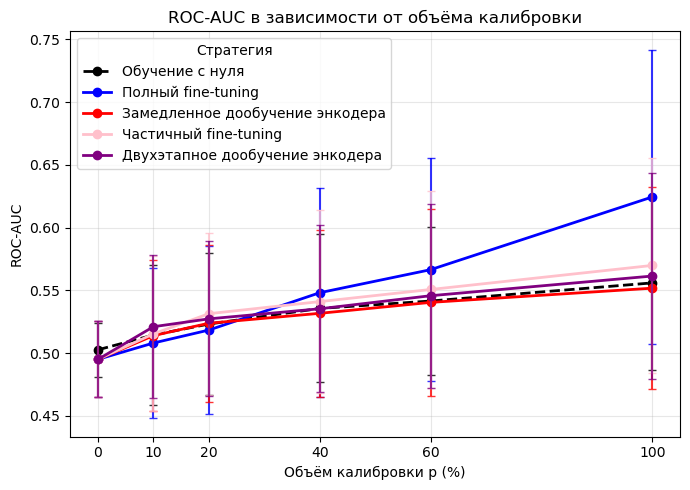

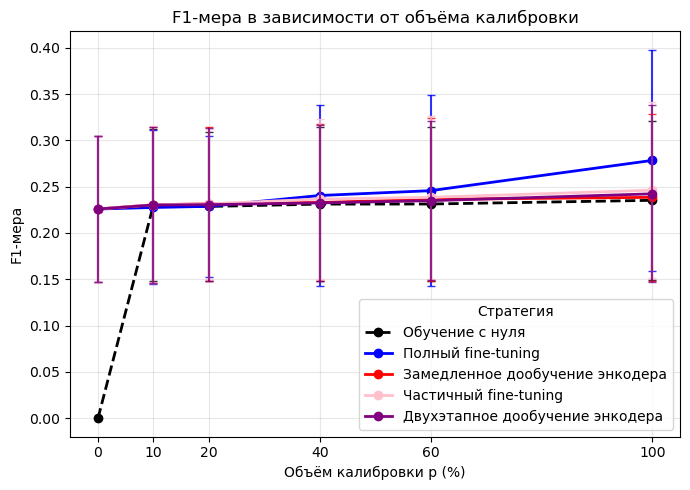

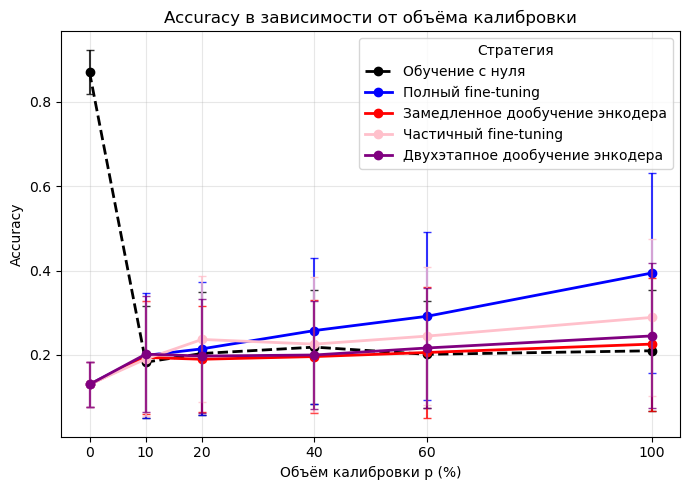

In [38]:
plot_metric("auc", "ROC-AUC")
plot_metric("f1", "F1-мера")
plot_metric("accuracy", "Accuracy")

In [25]:
def plot_clean(metric, ylabel):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    for strategy in sorted(plot_df["strategy"].unique()):
        sub = plot_df[plot_df["strategy"] == strategy]
        sub = sub.set_index("p").loc[p_values].reset_index()

        linestyle = "--" if strategy == "scratch" else "-"

        plt.plot(
            sub["p"],
            sub[f"{metric}_mean"],
            marker="o",
            color=COLORS[strategy],
            linewidth=2,
            linestyle=linestyle,
            label=STRATEGY_RU.get(strategy, strategy),
        )

    plt.xticks(p_values)
    plt.xlabel("Объём калибровки p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} в зависимости от объёма калибровки")

    plt.legend(title="Стратегия")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

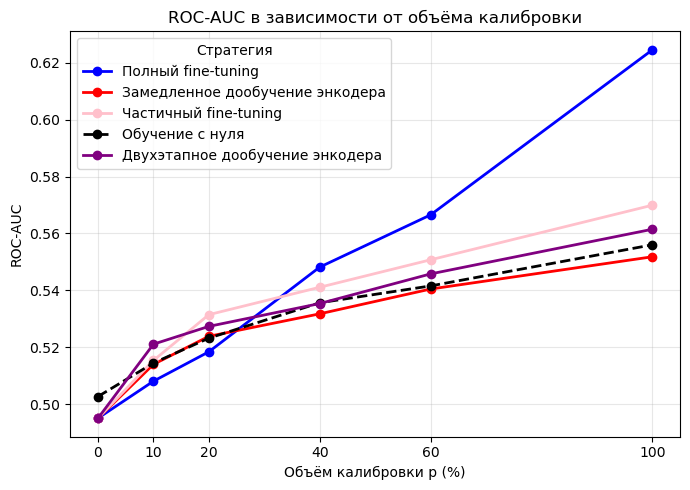

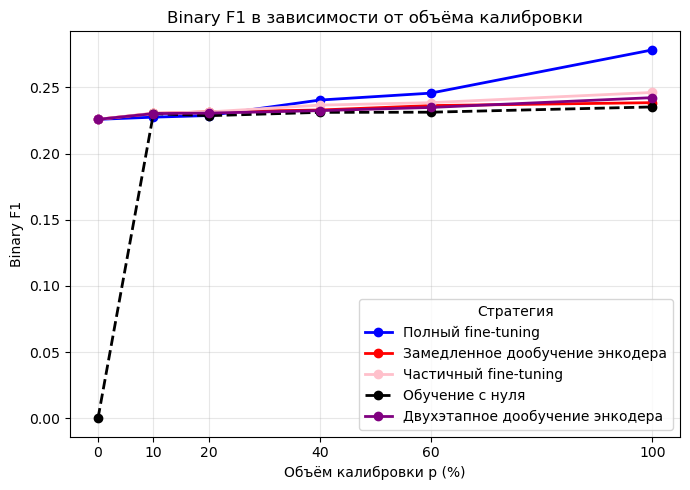

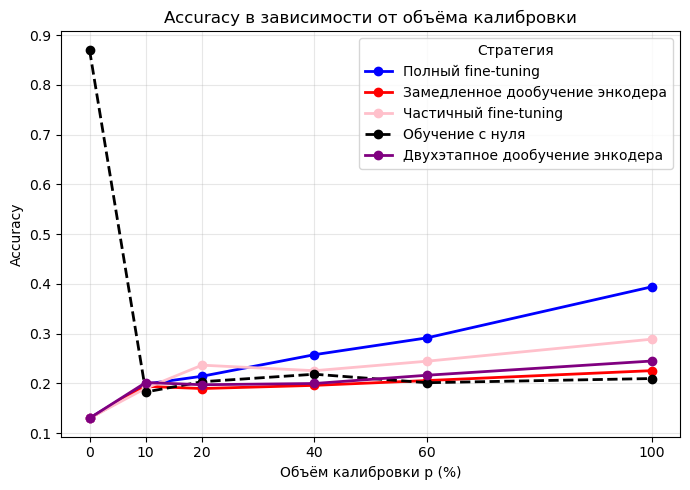

In [26]:
plot_clean("auc", "ROC-AUC")
plot_clean("f1", "Binary F1")
plot_clean("accuracy", "Accuracy")

#### Сохраняем графики

In [39]:
def save_plot(metric, ylabel, filename):
    draw_metric_plot(metric, ylabel)

    save_path = FIG_DIR / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.savefig(save_path.with_suffix(".pdf"))
    plt.close()

    print(f"Сохранено: {save_path}")

In [40]:
save_plot("auc", "ROC-AUC", "auc_vs_p.png")
save_plot("f1", "F1-мера", "f1_vs_p.png")
save_plot("accuracy", "Accuracy", "accuracy_vs_p.png")

Сохранено: analysis_outputs\figures\auc_vs_p.png
Сохранено: analysis_outputs\figures\f1_vs_p.png
Сохранено: analysis_outputs\figures\accuracy_vs_p.png


In [ ]:
def save_clean_plot(metric, ylabel, filename):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    for strategy in sorted(plot_df["strategy"].unique()):
        sub = plot_df[plot_df["strategy"] == strategy]
        sub = sub.set_index("p").loc[p_values].reset_index()

        if strategy == "scratch":
            linestyle = "--"
            linewidth = 3
        else:
            linestyle = "-"
            linewidth = 2

        plt.plot(
            sub["p"],
            sub[f"{metric}_mean"],
            marker="o",
            linestyle=linestyle,
            linewidth=linewidth,
            color=COLORS[strategy],
            label=strategy
        )

    plt.xticks(p_values)
    plt.xlabel("Calibration size p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs Calibration Size")

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300)
    plt.close()

In [32]:
save_clean_plot("auc", "ROC-AUC", "clean_auc_vs_p.png")
save_clean_plot("f1", "Binary F1", "clean_f1_vs_p.png")
save_clean_plot("accuracy", "Accuracy", "clean_accuracy_vs_p.png")

## Графики выигрыша относительно scratch

#### per-subject delta

In [41]:
metric_cols = ["auc", "f1", "accuracy"]

# scratch как база
df_scratch_base = (
    df_all[df_all["strategy"] == "scratch"]
    [["subject_id", "p"] + metric_cols]
    .rename(columns={m: f"{m}_scratch" for m in metric_cols})
    .copy()
)

# все не-scratch стратегии
df_non_scratch = df_all[df_all["strategy"] != "scratch"].copy()

# merge по subject_id и p
df_delta = df_non_scratch.merge(
    df_scratch_base,
    on=["subject_id", "p"],
    how="inner"
)

# считаем дельты
for m in metric_cols:
    df_delta[f"delta_{m}"] = df_delta[m] - df_delta[f"{m}_scratch"]

print("df_delta shape:", df_delta.shape)
display(df_delta.head())

df_delta shape: (1464, 16)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch,f1_scratch,accuracy_scratch,delta_auc,delta_f1,delta_accuracy
0,subj_051,0,full_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.499638,0.000000,0.882397,0.035314,0.210456,-0.764794
1,subj_051,0,low_lr_encoder,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.499638,0.000000,0.882397,0.035314,0.210456,-0.764794
2,subj_051,0,partial_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.499638,0.000000,0.882397,0.035314,0.210456,-0.764794
3,subj_051,0,warmup,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.499638,0.000000,0.882397,0.035314,0.210456,-0.764794
4,subj_051,10,full_ft,0.508474,0.212057,0.167790,0.119314,0.952229,0.004054,benchmark,0.550267,0.217163,0.330337,-0.041793,-0.005106,-0.162547


In [42]:
check_delta = (
    df_delta.groupby(["strategy", "p"])[["delta_auc", "delta_f1", "delta_accuracy"]]
    .agg(["mean", "std", "median"])
)

check_delta.columns = ["_".join(col) for col in check_delta.columns]
check_delta = check_delta.reset_index()

display(check_delta)

,strategy,p,delta_auc_mean,delta_auc_std,delta_auc_median,delta_f1_mean,delta_f1_std,delta_f1_median,delta_accuracy_mean,delta_accuracy_std,delta_accuracy_median
0,full_ft,0,-0.007618,0.032961,-0.013236,0.225901,0.078746,0.209900,-0.740226,0.106011,-0.765488
1,full_ft,10,-0.006366,0.038922,-0.001568,-0.002652,0.010547,0.000000,0.015994,0.162274,0.000000
2,full_ft,20,-0.004796,0.040320,-0.004641,0.000115,0.015398,0.000000,0.010971,0.137315,0.000000
3,full_ft,40,0.012519,0.049472,0.009975,0.009302,0.043941,0.001642,0.039276,0.122632,0.018430
4,full_ft,60,0.024956,0.045298,0.015071,0.014405,0.061145,0.001616,0.090120,0.179002,0.019683
5,full_ft,100,0.068460,0.087189,0.042894,0.043103,0.070019,0.010160,0.184362,0.209897,0.094907
6,low_lr_encoder,0,-0.007618,0.032961,-0.013236,0.225901,0.078746,0.209900,-0.740226,0.106011,-0.765488
7,low_lr_encoder,10,-0.000468,0.036930,0.006326,0.000190,0.007247,0.000000,0.011300,0.126325,0.000000
8,low_lr_encoder,20,0.000640,0.033840,-0.000311,0.002923,0.011345,0.000000,-0.013699,0.107126,0.000000
9,low_lr_encoder,40,-0.003884,0.039007,0.002141,0.001767,0.007952,0.000383,-0.022370,0.103829,-0.003017


#### Функция для delta-графика

In [43]:
def plot_delta_metric(delta_metric, ylabel):
    plt.figure(figsize=(8, 5))

    p_values = [0, 10, 20, 40, 60, 100]
    strategies = sorted(df_delta["strategy"].unique())

    for strategy in strategies:
        sub = (
            df_delta[df_delta["strategy"] == strategy]
            .groupby("p")[delta_metric]
            .agg(["mean", "std"])
            .reset_index()
            .set_index("p")
            .loc[p_values]
            .reset_index()
        )

        x = sub["p"]
        y = sub["mean"]
        yerr = sub["std"]

        plt.plot(x, y, marker="o", label=strategy, color=COLORS[strategy])
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.15, color=COLORS[strategy])

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(p_values)
    plt.xlabel("Calibration size p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} relative to Scratch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Строим Δ-графики

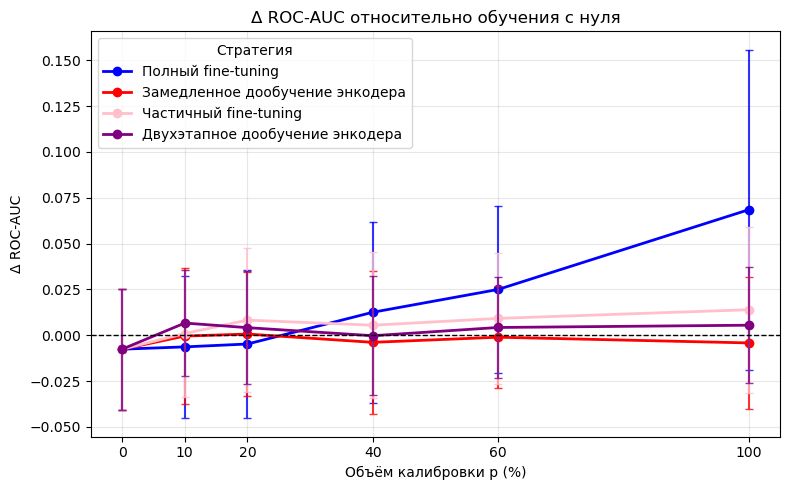

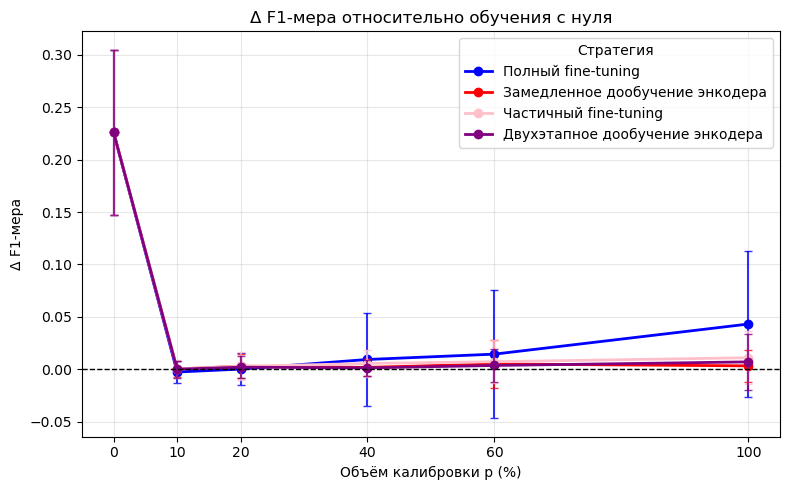

In [45]:
plot_delta_metric(df_delta, "delta_auc", "Δ ROC-AUC")
plot_delta_metric(df_delta, "delta_f1", "Δ F1-мера")

#### Сохраняем Δ-графики

In [47]:
save_delta_metric_plot(df_delta, "delta_auc", "Δ ROC-AUC", "delta_auc_vs_scratch.png")
save_delta_metric_plot(df_delta, "delta_f1", "Δ F1-мера", "delta_f1_vs_scratch.png")
save_delta_metric_plot(df_delta, "delta_accuracy", "Δ Accuracy", "delta_accuracy_vs_scratch.png")

Сохранено: analysis_outputs\figures\delta_auc_vs_scratch.png
Сохранено: analysis_outputs\figures\delta_f1_vs_scratch.png
Сохранено: analysis_outputs\figures\delta_accuracy_vs_scratch.png


## Парные статистические тесты

In [48]:
# Импорт статистики
from scipy.stats import wilcoxon

#### Функция для одного теста

In [49]:
def run_wilcoxon(df, metric):
    values = df[metric].dropna()

    if len(values) < 5:
        return np.nan

    try:
        stat, p = wilcoxon(values)
        return p
    except:
        return np.nan

#### Запускаем тесты

In [50]:
results = []

strategies = sorted(df_delta["strategy"].unique())
p_values = sorted(df_delta["p"].unique())

metrics = ["delta_auc", "delta_f1", "delta_accuracy"]

for p in p_values:
    for strategy in strategies:
        sub = df_delta[
            (df_delta["p"] == p) &
            (df_delta["strategy"] == strategy)
        ]

        for metric in metrics:
            p_val = run_wilcoxon(sub, metric)

            results.append({
                "p": p,
                "strategy": strategy,
                "metric": metric,
                "n": len(sub),
                "mean": sub[metric].mean(),
                "median": sub[metric].median(),
                "p_value": p_val
            })

stats_df = pd.DataFrame(results)
display(stats_df.head())

,p,strategy,metric,n,mean,median,p_value
0,0,full_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03
1,0,full_ft,delta_f1,61,0.225901,0.209900,1.109647e-11
2,0,full_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11
3,0,low_lr_encoder,delta_auc,61,-0.007618,-0.013236,4.205307e-03
4,0,low_lr_encoder,delta_f1,61,0.225901,0.209900,1.109647e-11


#### Поправка на множественные сравнения

In [51]:
from statsmodels.stats.multitest import multipletests

stats_df["p_adj"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]
stats_df["significant"] = stats_df["p_adj"] < 0.05

display(stats_df)

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
0,0,full_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
1,0,full_ft,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
2,0,full_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
3,0,low_lr_encoder,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
4,0,low_lr_encoder,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
5,0,low_lr_encoder,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
6,0,partial_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
7,0,partial_ft,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
8,0,partial_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
9,0,warmup,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True


#### Только значимые строки

In [52]:
significant_df = stats_df[stats_df["significant"] == True]

display(significant_df)

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
0,0,full_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
1,0,full_ft,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
2,0,full_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
3,0,low_lr_encoder,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
4,0,low_lr_encoder,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
5,0,low_lr_encoder,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
6,0,partial_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
7,0,partial_ft,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
8,0,partial_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
9,0,warmup,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True


#### Только по AUC

In [53]:
sig_auc_positive = stats_df[
    (stats_df["metric"] == "delta_auc") &
    (stats_df["significant"] == True) &
    (stats_df["mean"] > 0)
]

display(sig_auc_positive.sort_values(["p", "strategy"]))

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
48,60,full_ft,delta_auc,61,0.024956,0.015071,1.661775e-05,0.000100,True
60,100,full_ft,delta_auc,61,0.068460,0.042894,2.028157e-07,0.000001,True


In [54]:
for strategy in sorted(sig_auc_positive["strategy"].unique()):
    p_list = sig_auc_positive[sig_auc_positive["strategy"] == strategy]["p"].tolist()
    print(f"{strategy}: significant improvement at p = {p_list}")

full_ft: significant improvement at p = [60, 100]


## SSL(p) vs Scratch(100)

- для каждого субъекта берём scratch при p=100 как референс;
- сравниваем с этим же субъектом при SSL-стратегии и меньшем p;
- считаем разность:
    - metric_ssl_p - metric_scratch_100
- дальше уже смотрим:
    - среднее / медиану
    - сколько раз разность ≥ 0
    - Wilcoxon
    - поправку на множественные сравнения

#### Собираем таблицу сравнений с scratch(100)

In [54]:
metric_cols = ["auc", "f1", "accuracy"]

# База: scratch только при p=100
df_scratch_100 = (
    df_all[
        (df_all["strategy"] == "scratch") &
        (df_all["p"] == 100)
    ][["subject_id"] + metric_cols]
    .rename(columns={m: f"{m}_scratch100" for m in metric_cols})
    .copy()
)

print("df_scratch_100 shape:", df_scratch_100.shape)
display(df_scratch_100.head())

df_scratch_100 shape: (61, 4)


,subject_id,auc_scratch100,f1_scratch100,accuracy_scratch100
1469,subj_051,0.538567,0.210456,0.117603
1475,subj_052,0.540498,0.211925,0.170373
1481,subj_053,0.520240,0.211170,0.183257
1487,subj_055,0.560084,0.213135,0.133106
1493,subj_056,0.495432,0.212002,0.150801


#### Берём все SSL-стратегии и мержим с scratch(100)

In [55]:
df_ssl = df_all[df_all["strategy"] != "scratch"].copy()

df_vs_s100 = df_ssl.merge(
    df_scratch_100,
    on="subject_id",
    how="inner"
)

for m in metric_cols:
    df_vs_s100[f"delta_vs_scratch100_{m}"] = df_vs_s100[m] - df_vs_s100[f"{m}_scratch100"]

print("df_vs_s100 shape:", df_vs_s100.shape)
display(df_vs_s100.head())

df_vs_s100 shape: (1464, 16)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch100,f1_scratch100,accuracy_scratch100,delta_vs_scratch100_auc,delta_vs_scratch100_f1,delta_vs_scratch100_accuracy
0,subj_051,0,full_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.538567,0.210456,0.117603,-0.003615,0.000000,0.000000
1,subj_051,0,low_lr_encoder,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.538567,0.210456,0.117603,-0.003615,0.000000,0.000000
2,subj_051,0,partial_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.538567,0.210456,0.117603,-0.003615,0.000000,0.000000
3,subj_051,0,warmup,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.538567,0.210456,0.117603,-0.003615,0.000000,0.000000
4,subj_051,10,full_ft,0.508474,0.212057,0.167790,0.119314,0.952229,0.004054,benchmark,0.538567,0.210456,0.117603,-0.030093,0.001601,0.050187


##### Быстрая sanity-check проверка

In [56]:
print("Strategies:", sorted(df_vs_s100["strategy"].unique()))
print("p values:", sorted(df_vs_s100["p"].unique()))
print("Subjects:", df_vs_s100["subject_id"].nunique())

Strategies: ['full_ft', 'low_lr_encoder', 'partial_ft', 'warmup']
p values: [np.int64(0), np.int64(10), np.int64(20), np.int64(40), np.int64(60), np.int64(100)]
Subjects: 61


#### Сводная таблица по разностям относительно scratch(100)

In [57]:
delta_cols_s100 = [
    "delta_vs_scratch100_auc",
    "delta_vs_scratch100_f1",
    "delta_vs_scratch100_accuracy"
]

summary_vs_s100 = (
    df_vs_s100
    .groupby(["strategy", "p"])[delta_cols_s100]
    .agg(["mean", "std", "median"])
)

summary_vs_s100.columns = ["_".join(col) for col in summary_vs_s100.columns]
summary_vs_s100 = summary_vs_s100.reset_index()

display(summary_vs_s100)

,strategy,p,delta_vs_scratch100_auc_mean,delta_vs_scratch100_auc_std,delta_vs_scratch100_auc_median,delta_vs_scratch100_f1_mean,delta_vs_scratch100_f1_std,delta_vs_scratch100_f1_median,delta_vs_scratch100_accuracy_mean,delta_vs_scratch100_accuracy_std,delta_vs_scratch100_accuracy_median
0,full_ft,0,-0.060910,0.058414,-0.050561,-0.009375,0.042870,-0.000240,-0.079785,0.137958,-0.028326
1,full_ft,10,-0.047899,0.055387,-0.036762,-0.007729,0.025327,-0.000616,-0.011066,0.158381,-0.009395
2,full_ft,20,-0.037573,0.051481,-0.022686,-0.006509,0.020661,-0.000240,0.004564,0.128206,-0.006574
3,full_ft,40,-0.007836,0.041084,-0.005568,0.005201,0.034694,0.000676,0.047916,0.145514,0.024830
4,full_ft,60,0.010515,0.038537,0.002594,0.010419,0.046807,0.000509,0.081700,0.161762,0.035402
5,full_ft,100,0.068460,0.087189,0.042894,0.043103,0.070019,0.010160,0.184362,0.209897,0.094907
6,low_lr_encoder,0,-0.060910,0.058414,-0.050561,-0.009375,0.042870,-0.000240,-0.079785,0.137958,-0.028326
7,low_lr_encoder,10,-0.042001,0.051354,-0.031433,-0.004888,0.018870,-0.000799,-0.015761,0.134080,-0.006574
8,low_lr_encoder,20,-0.032137,0.045354,-0.023239,-0.003701,0.016088,-0.000240,-0.020107,0.098590,-0.003378
9,low_lr_encoder,40,-0.024240,0.042342,-0.012818,-0.002333,0.015533,0.000000,-0.013729,0.092303,-0.000785


#### Считаем, сколько субъектов не хуже scratch(100)

In [58]:
rows = []

for (strategy, p), sub in df_vs_s100.groupby(["strategy", "p"]):
    row = {
        "strategy": strategy,
        "p": p,
        "n_subjects": len(sub)
    }
    for m in metric_cols:
        delta_col = f"delta_vs_scratch100_{m}"
        row[f"n_ge_0_{m}"] = int((sub[delta_col] >= 0).sum())
        row[f"frac_ge_0_{m}"] = float((sub[delta_col] >= 0).mean())
    rows.append(row)

ge0_vs_s100 = pd.DataFrame(rows).sort_values(["strategy", "p"])
display(ge0_vs_s100)

,strategy,p,n_subjects,n_ge_0_auc,frac_ge_0_auc,n_ge_0_f1,frac_ge_0_f1,n_ge_0_accuracy,frac_ge_0_accuracy
0,full_ft,0,61,3,0.049180,27,0.442623,8,0.131148
1,full_ft,10,61,7,0.114754,22,0.360656,18,0.295082
2,full_ft,20,61,9,0.147541,26,0.426230,22,0.360656
3,full_ft,40,61,23,0.377049,39,0.639344,38,0.622951
4,full_ft,60,61,34,0.557377,37,0.606557,44,0.721311
5,full_ft,100,61,47,0.770492,48,0.786885,47,0.770492
6,low_lr_encoder,0,61,3,0.049180,27,0.442623,8,0.131148
7,low_lr_encoder,10,61,6,0.098361,22,0.360656,25,0.409836
8,low_lr_encoder,20,61,10,0.163934,26,0.426230,25,0.409836
9,low_lr_encoder,40,61,20,0.327869,34,0.557377,30,0.491803


#### Wilcoxon для SSL(p) vs scratch(100)

In [59]:
from scipy.stats import wilcoxon

def run_wilcoxon(values):
    values = pd.Series(values).dropna()
    if len(values) < 5:
        return np.nan
    try:
        stat, p = wilcoxon(values)
        return p
    except Exception:
        return np.nan

In [60]:
results_vs_s100 = []

for (strategy, p), sub in df_vs_s100.groupby(["strategy", "p"]):
    for m in metric_cols:
        delta_col = f"delta_vs_scratch100_{m}"
        vals = sub[delta_col].dropna()

        results_vs_s100.append({
            "strategy": strategy,
            "p": p,
            "metric": m,
            "n": len(vals),
            "mean_diff": vals.mean(),
            "std_diff": vals.std(),
            "median_diff": vals.median(),
            "n_ge_0": int((vals >= 0).sum()),
            "frac_ge_0": float((vals >= 0).mean()),
            "p_value": run_wilcoxon(vals)
        })

stats_vs_s100 = pd.DataFrame(results_vs_s100).sort_values(["metric", "strategy", "p"])
display(stats_vs_s100.head(20))

,strategy,p,metric,n,mean_diff,std_diff,median_diff,n_ge_0,frac_ge_0,p_value
2,full_ft,0,accuracy,61,-0.079785,0.137958,-0.028326,8,0.131148,2.259767e-10
5,full_ft,10,accuracy,61,-0.011066,0.158381,-0.009395,18,0.295082,3.908074e-02
8,full_ft,20,accuracy,61,0.004564,0.128206,-0.006574,22,0.360656,2.642930e-01
11,full_ft,40,accuracy,61,0.047916,0.145514,0.024830,38,0.622951,1.357989e-02
14,full_ft,60,accuracy,61,0.081700,0.161762,0.035402,44,0.721311,1.147798e-04
17,full_ft,100,accuracy,61,0.184362,0.209897,0.094907,47,0.770492,1.530741e-07
20,low_lr_encoder,0,accuracy,61,-0.079785,0.137958,-0.028326,8,0.131148,2.259767e-10
23,low_lr_encoder,10,accuracy,61,-0.015761,0.134080,-0.006574,25,0.409836,1.641215e-01
26,low_lr_encoder,20,accuracy,61,-0.020107,0.098590,-0.003378,25,0.409836,1.330849e-01
29,low_lr_encoder,40,accuracy,61,-0.013729,0.092303,-0.000785,30,0.491803,2.961178e-01


##### Поправка на множественные сравнения

In [61]:
from statsmodels.stats.multitest import multipletests

stats_vs_s100 = stats_vs_s100.copy()
stats_vs_s100["p_adj"] = multipletests(stats_vs_s100["p_value"], method="fdr_bh")[1]
stats_vs_s100["significant"] = stats_vs_s100["p_adj"] < 0.05

display(stats_vs_s100)

,strategy,p,metric,n,mean_diff,std_diff,median_diff,n_ge_0,frac_ge_0,p_value,p_adj,significant
2,full_ft,0,accuracy,61,-0.079785,0.137958,-0.028326,8,0.131148,2.259767e-10,2.033790e-09,True
5,full_ft,10,accuracy,61,-0.011066,0.158381,-0.009395,18,0.295082,3.908074e-02,6.789098e-02,False
8,full_ft,20,accuracy,61,0.004564,0.128206,-0.006574,22,0.360656,2.642930e-01,3.459836e-01,False
11,full_ft,40,accuracy,61,0.047916,0.145514,0.024830,38,0.622951,1.357989e-02,2.698820e-02,True
14,full_ft,60,accuracy,61,0.081700,0.161762,0.035402,44,0.721311,1.147798e-04,3.593106e-04,True
17,full_ft,100,accuracy,61,0.184362,0.209897,0.094907,47,0.770492,1.530741e-07,6.888335e-07,True
20,low_lr_encoder,0,accuracy,61,-0.079785,0.137958,-0.028326,8,0.131148,2.259767e-10,2.033790e-09,True
23,low_lr_encoder,10,accuracy,61,-0.015761,0.134080,-0.006574,25,0.409836,1.641215e-01,2.348671e-01,False
26,low_lr_encoder,20,accuracy,61,-0.020107,0.098590,-0.003378,25,0.409836,1.330849e-01,1.996274e-01,False
29,low_lr_encoder,40,accuracy,61,-0.013729,0.092303,-0.000785,30,0.491803,2.961178e-01,3.553413e-01,False


#### Сохраняем таблицы

In [64]:
summary_vs_s100.to_csv(TAB_DIR / "summary_vs_scratch100.csv", index=False)
ge0_vs_s100.to_csv(TAB_DIR / "ge0_vs_scratch100.csv", index=False)
stats_vs_s100.to_csv(TAB_DIR / "paired_stats_vs_scratch100.csv", index=False)

#### По AUC: значимые и/или близкие результаты

In [62]:
auc_vs_s100 = stats_vs_s100[stats_vs_s100["metric"] == "auc"].copy()
display(auc_vs_s100.sort_values(["strategy", "p"]))

,strategy,p,metric,n,mean_diff,std_diff,median_diff,n_ge_0,frac_ge_0,p_value,p_adj,significant
0,full_ft,0,auc,61,-0.060910,0.058414,-0.050561,3,0.049180,3.798159e-11,6.836685e-10,True
3,full_ft,10,auc,61,-0.047899,0.055387,-0.036762,7,0.114754,1.435135e-09,1.033297e-08,True
6,full_ft,20,auc,61,-0.037573,0.051481,-0.022686,9,0.147541,2.156246e-08,1.194228e-07,True
9,full_ft,40,auc,61,-0.007836,0.041084,-0.005568,23,0.377049,1.899062e-01,2.629471e-01,False
12,full_ft,60,auc,61,0.010515,0.038537,0.002594,34,0.557377,3.960307e-02,6.789098e-02,False
15,full_ft,100,auc,61,0.068460,0.087189,0.042894,47,0.770492,2.028157e-07,8.589840e-07,True
18,low_lr_encoder,0,auc,61,-0.060910,0.058414,-0.050561,3,0.049180,3.798159e-11,6.836685e-10,True
21,low_lr_encoder,10,auc,61,-0.042001,0.051354,-0.031433,6,0.098361,9.587303e-10,7.669842e-09,True
24,low_lr_encoder,20,auc,61,-0.032137,0.045354,-0.023239,10,0.163934,6.744199e-08,3.468445e-07,True
27,low_lr_encoder,40,auc,61,-0.024240,0.042342,-0.012818,20,0.327869,4.868335e-05,1.669143e-04,True


In [66]:
auc_not_worse = auc_vs_s100[auc_vs_s100["mean_diff"] >= 0].copy()
display(auc_not_worse.sort_values(["strategy", "p"]))

,strategy,p,metric,n,mean_diff,std_diff,median_diff,n_ge_0,frac_ge_0,p_value,p_adj,significant
12,full_ft,60,auc,61,0.010515,0.038537,0.002594,34,0.557377,3.960307e-02,6.789098e-02,False
15,full_ft,100,auc,61,0.068460,0.087189,0.042894,47,0.770492,2.028157e-07,8.589840e-07,True
51,partial_ft,100,auc,61,0.013906,0.045324,0.004526,34,0.557377,6.754709e-02,1.105316e-01,False
69,warmup,100,auc,61,0.005457,0.031773,0.002927,35,0.573770,2.345383e-01,3.127177e-01,False


In [67]:
auc_better_sig = auc_vs_s100[
    (auc_vs_s100["mean_diff"] > 0) &
    (auc_vs_s100["significant"])
].copy()

display(auc_better_sig.sort_values(["strategy", "p"]))

,strategy,p,metric,n,mean_diff,std_diff,median_diff,n_ge_0,frac_ge_0,p_value,p_adj,significant
15,full_ft,100,auc,61,0.06846,0.087189,0.042894,47,0.770492,2.028157e-07,8.589840e-07,True


##### Случаи, где SSL пока хуже, но уже у большой доли субъектов не хуже

In [63]:
auc_promising = auc_vs_s100[
    (auc_vs_s100["frac_ge_0"] >= 0.5)
].copy()

display(auc_promising.sort_values(["strategy", "p"]))

,strategy,p,metric,n,mean_diff,std_diff,median_diff,n_ge_0,frac_ge_0,p_value,p_adj,significant
12,full_ft,60,auc,61,0.010515,0.038537,0.002594,34,0.557377,3.960307e-02,6.789098e-02,False
15,full_ft,100,auc,61,0.068460,0.087189,0.042894,47,0.770492,2.028157e-07,8.589840e-07,True
51,partial_ft,100,auc,61,0.013906,0.045324,0.004526,34,0.557377,6.754709e-02,1.105316e-01,False
69,warmup,100,auc,61,0.005457,0.031773,0.002927,35,0.573770,2.345383e-01,3.127177e-01,False


In [64]:
for strategy in sorted(auc_vs_s100["strategy"].unique()):
    sub = auc_vs_s100[auc_vs_s100["strategy"] == strategy].sort_values("p")
    print(f"\n{strategy}")
    display(sub[["p", "n", "mean_diff", "median_diff", "frac_ge_0", "p_value", "p_adj", "significant"]])


full_ft


,p,n,mean_diff,median_diff,frac_ge_0,p_value,p_adj,significant
0,0,61,-0.060910,-0.050561,0.049180,3.798159e-11,6.836685e-10,True
3,10,61,-0.047899,-0.036762,0.114754,1.435135e-09,1.033297e-08,True
6,20,61,-0.037573,-0.022686,0.147541,2.156246e-08,1.194228e-07,True
9,40,61,-0.007836,-0.005568,0.377049,1.899062e-01,2.629471e-01,False
12,60,61,0.010515,0.002594,0.557377,3.960307e-02,6.789098e-02,False
15,100,61,0.068460,0.042894,0.770492,2.028157e-07,8.589840e-07,True



low_lr_encoder


,p,n,mean_diff,median_diff,frac_ge_0,p_value,p_adj,significant
18,0,61,-0.060910,-0.050561,0.049180,3.798159e-11,6.836685e-10,True
21,10,61,-0.042001,-0.031433,0.098361,9.587303e-10,7.669842e-09,True
24,20,61,-0.032137,-0.023239,0.163934,6.744199e-08,3.468445e-07,True
27,40,61,-0.024240,-0.012818,0.327869,4.868335e-05,1.669143e-04,True
30,60,61,-0.015534,-0.009505,0.327869,9.753007e-05,3.191893e-04,True
33,100,61,-0.004203,-0.001297,0.491803,6.901555e-01,7.307529e-01,False



partial_ft


,p,n,mean_diff,median_diff,frac_ge_0,p_value,p_adj,significant
36,0,61,-0.060910,-0.050561,0.049180,3.798159e-11,6.836685e-10,True
39,10,61,-0.040616,-0.025863,0.114754,1.792497e-09,1.173271e-08,True
42,20,61,-0.024535,-0.016493,0.229508,2.497797e-06,8.992069e-06,True
45,40,61,-0.014910,-0.012714,0.360656,3.839360e-03,9.872640e-03,True
48,60,61,-0.005263,-0.005980,0.377049,1.948064e-01,2.646426e-01,False
51,100,61,0.013906,0.004526,0.557377,6.754709e-02,1.105316e-01,False



warmup


,p,n,mean_diff,median_diff,frac_ge_0,p_value,p_adj,significant
54,0,61,-0.060910,-0.050561,0.049180,3.798159e-11,6.836685e-10,True
57,10,61,-0.034904,-0.027210,0.098361,4.124984e-09,2.474991e-08,True
60,20,61,-0.028653,-0.018695,0.196721,2.554761e-07,1.021904e-06,True
63,40,61,-0.020629,-0.016069,0.245902,2.327626e-06,8.820479e-06,True
66,60,61,-0.010219,-0.008349,0.344262,7.301590e-03,1.752382e-02,True
69,100,61,0.005457,0.002927,0.573770,2.345383e-01,3.127177e-01,False


### SSL(p_small) vs scratch(p_big)

In [65]:
# scratch(p_ref)
def build_reference(df_all, p_ref):
    return (
        df_all[
            (df_all["strategy"] == "scratch") &
            (df_all["p"] == p_ref)
        ][["subject_id", "auc", "f1", "accuracy"]]
        .rename(columns={
            "auc": f"auc_scratch{p_ref}",
            "f1": f"f1_scratch{p_ref}",
            "accuracy": f"accuracy_scratch{p_ref}"
        })
        .copy()
    )

In [66]:
# Сравнение с SSL
def compare_with_reference(df_all, p_ref):
    metric_cols = ["auc", "f1", "accuracy"]

    df_ref = build_reference(df_all, p_ref)

    df_ssl = df_all[df_all["strategy"] != "scratch"].copy()

    df_cmp = df_ssl.merge(df_ref, on="subject_id", how="inner")

    for m in metric_cols:
        df_cmp[f"delta_vs_scratch{p_ref}_{m}"] = (
            df_cmp[m] - df_cmp[f"{m}_scratch{p_ref}"]
        )

    return df_cmp

#### Запускаем для p_ref = 60

In [67]:
df_vs_s60 = compare_with_reference(df_all, p_ref=60)
display(df_vs_s60.head())

,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch60,f1_scratch60,accuracy_scratch60,delta_vs_scratch60_auc,delta_vs_scratch60_f1,delta_vs_scratch60_accuracy
0,subj_051,0,full_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.551749,0.210456,0.117603,-0.016797,0.000000,0.000000
1,subj_051,0,low_lr_encoder,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.551749,0.210456,0.117603,-0.016797,0.000000,0.000000
2,subj_051,0,partial_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.551749,0.210456,0.117603,-0.016797,0.000000,0.000000
3,subj_051,0,warmup,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.551749,0.210456,0.117603,-0.016797,0.000000,0.000000
4,subj_051,10,full_ft,0.508474,0.212057,0.167790,0.119314,0.952229,0.004054,benchmark,0.551749,0.210456,0.117603,-0.043275,0.001601,0.050187


In [68]:
results_s60 = []

for (strategy, p), sub in df_vs_s60.groupby(["strategy", "p"]):
    for m in ["auc", "f1", "accuracy"]:
        delta_col = f"delta_vs_scratch60_{m}"
        vals = sub[delta_col].dropna()

        results_s60.append({
            "strategy": strategy,
            "p": p,
            "metric": m,
            "n": len(vals),
            "mean_diff": vals.mean(),
            "median_diff": vals.median(),
            "frac_ge_0": (vals >= 0).mean(),
            "p_value": run_wilcoxon(vals)
        })

stats_s60 = pd.DataFrame(results_s60)

In [70]:
# Поправка на множественное сравнение
from statsmodels.stats.multitest import multipletests

stats_s60["p_adj"] = multipletests(stats_s60["p_value"], method="fdr_bh")[1]
stats_s60["significant"] = stats_s60["p_adj"] < 0.05

In [71]:
auc_s60 = stats_s60[stats_s60["metric"] == "auc"].copy()
display(auc_s60.sort_values(["strategy", "p"]))

,strategy,p,metric,n,mean_diff,median_diff,frac_ge_0,p_value,p_adj,significant
0,full_ft,0,auc,61,-0.046469,-0.043391,0.065574,9.464113e-11,1.703540e-09,True
3,full_ft,10,auc,61,-0.033458,-0.028364,0.180328,1.607204e-07,9.643222e-07,True
6,full_ft,20,auc,61,-0.023133,-0.016052,0.278689,9.467894e-05,3.587834e-04,True
9,full_ft,40,auc,61,0.006604,0.003729,0.622951,2.373777e-01,3.351215e-01,False
12,full_ft,60,auc,61,0.024956,0.015071,0.721311,1.661775e-05,7.477986e-05,True
15,full_ft,100,auc,61,0.082901,0.054507,0.885246,5.563440e-10,8.011354e-09,True
18,low_lr_encoder,0,auc,61,-0.046469,-0.043391,0.065574,9.464113e-11,1.703540e-09,True
21,low_lr_encoder,10,auc,61,-0.027560,-0.022475,0.262295,7.601067e-07,4.207886e-06,True
24,low_lr_encoder,20,auc,61,-0.017697,-0.013477,0.327869,4.577269e-05,1.830908e-04,True
27,low_lr_encoder,40,auc,61,-0.009799,-0.008379,0.409836,6.863215e-02,1.205248e-01,False


##### Отбор случаев, где при меньшем объёме калибровочных данных результат не стал хуже


In [72]:
p_ref = 60

filtered = stats_s60[
    (stats_s60["metric"] == "auc") &
    (stats_s60["p"] < p_ref) &
    (
        (stats_s60["mean_diff"] >= 0) |
        (stats_s60["median_diff"] >= 0)
    )
].copy()

display(filtered.sort_values(["strategy", "p"]))

,strategy,p,metric,n,mean_diff,median_diff,frac_ge_0,p_value,p_adj,significant
9,full_ft,40,auc,61,0.006604,0.003729,0.622951,0.237378,0.335121,False


##### График

In [73]:
df_vs_s60 = compare_with_reference(df_all, p_ref=60)

# агрегируем
plot_s60 = (
    df_vs_s60[df_vs_s60["strategy"] == "full_ft"]
    .groupby("p")["delta_vs_scratch60_auc"]
    .agg(["mean", "std"])
    .reset_index()
)

display(plot_s60)

,p,mean,std
0,0,-0.046469,0.046937
1,10,-0.033458,0.045820
2,20,-0.023133,0.043849
3,40,0.006604,0.044152
4,60,0.024956,0.045298
5,100,0.082901,0.087943


In [78]:
def plot_delta_vs_scratch60(plot_s60, save_path=None):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    sub = plot_s60.set_index("p").loc[p_values].reset_index()

    x = sub["p"]
    y = sub["mean"]
    yerr = sub["std"]

    # линия
    plt.plot(
        x, y,
        marker="o",
        linewidth=2,
        color=COLORS["full_ft"],
        label="'Полный fine-tuning' (p=60) vs 'Обучение с нуля' "
    )

    # усики вместо fill_between
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt="none",
        ecolor=COLORS["full_ft"],
        capsize=3,
        alpha=0.8
    )

    # линия нуля
    plt.axhline(0, linestyle="--", linewidth=1, color="black")

    plt.xticks(p_values)
    plt.xlabel("Объём калибровки p (%)")
    plt.ylabel("Δ ROC-AUC относительно обучения с нуля (p=60)")
    plt.title("Относительное качество модели")

    plt.legend(title="Сравнение")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Сохранено: {save_path}")
    else:
        plt.show()

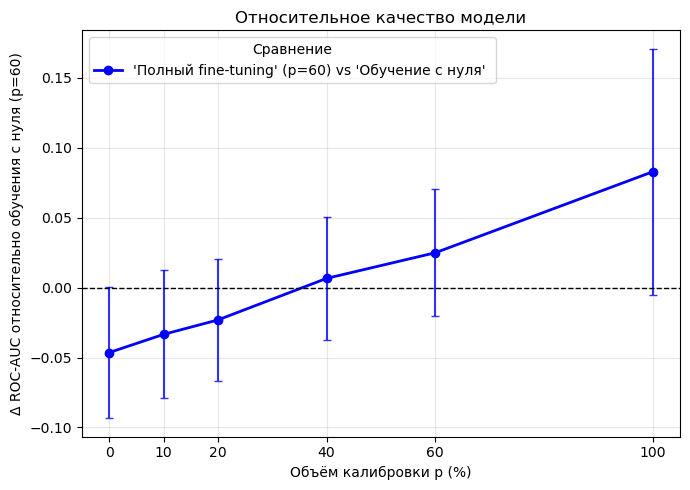

In [79]:
plot_delta_vs_scratch60(plot_s60)

In [81]:
plot_delta_vs_scratch60(
    plot_s60,
    save_path=FIG_DIR / "delta_auc_vs_scratch60.png"
)

Сохранено: analysis_outputs\figures\delta_auc_vs_scratch60.png


#### Запускаем для p_ref = 40

In [80]:
df_vs_s40 = compare_with_reference(df_all, p_ref=40)
display(df_vs_s40.head())

,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch40,f1_scratch40,accuracy_scratch40,delta_vs_scratch40_auc,delta_vs_scratch40_f1,delta_vs_scratch40_accuracy
0,subj_051,0,full_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.563142,0.213539,0.351685,-0.028190,-0.003084,-0.234082
1,subj_051,0,low_lr_encoder,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.563142,0.213539,0.351685,-0.028190,-0.003084,-0.234082
2,subj_051,0,partial_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.563142,0.213539,0.351685,-0.028190,-0.003084,-0.234082
3,subj_051,0,warmup,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.563142,0.213539,0.351685,-0.028190,-0.003084,-0.234082
4,subj_051,10,full_ft,0.508474,0.212057,0.167790,0.119314,0.952229,0.004054,benchmark,0.563142,0.213539,0.351685,-0.054668,-0.001483,-0.183895


In [82]:
results_s40 = []

for (strategy, p), sub in df_vs_s40.groupby(["strategy", "p"]):
    for m in ["auc", "f1", "accuracy"]:
        delta_col = f"delta_vs_scratch40_{m}"
        vals = sub[delta_col].dropna()

        results_s40.append({
            "strategy": strategy,
            "p": p,
            "metric": m,
            "n": len(vals),
            "mean_diff": vals.mean(),
            "median_diff": vals.median(),
            "frac_ge_0": (vals >= 0).mean(),
            "p_value": run_wilcoxon(vals)
        })

stats_s40 = pd.DataFrame(results_s40)

In [83]:
# Поправка на множественное сравнение
from statsmodels.stats.multitest import multipletests

stats_s40["p_adj"] = multipletests(stats_s40["p_value"], method="fdr_bh")[1]
stats_s40["significant"] = stats_s40["p_adj"] < 0.05

In [84]:
auc_s40 = stats_s40[stats_s40["metric"] == "auc"].copy()
display(auc_s40.sort_values(["strategy", "p"]))

,strategy,p,metric,n,mean_diff,median_diff,frac_ge_0,p_value,p_adj,significant
0,full_ft,0,auc,61,-0.040555,-0.032588,0.163934,7.863416e-09,5.661659e-08,True
3,full_ft,10,auc,61,-0.027543,-0.022272,0.262295,4.213408e-06,2.528045e-05,True
6,full_ft,20,auc,61,-0.017218,-0.007404,0.377049,9.415878e-03,2.337735e-02,True
9,full_ft,40,auc,61,0.012519,0.009975,0.655738,2.525795e-02,5.195921e-02,False
12,full_ft,60,auc,61,0.030871,0.021327,0.754098,8.040786e-06,4.453358e-05,True
15,full_ft,100,auc,61,0.088816,0.053841,0.901639,7.648903e-10,3.241461e-08,True
18,low_lr_encoder,0,auc,61,-0.040555,-0.032588,0.163934,7.863416e-09,5.661659e-08,True
21,low_lr_encoder,10,auc,61,-0.021646,-0.012985,0.360656,3.427882e-04,1.234037e-03,True
24,low_lr_encoder,20,auc,61,-0.011782,-0.007649,0.377049,4.468732e-02,7.963837e-02,False
27,low_lr_encoder,40,auc,61,-0.003884,0.002141,0.540984,7.766252e-01,8.737034e-01,False


##### Отбор случаев, где при меньшем объёме калибровочных данных auc статистически лучше

In [85]:
p_ref = 40

filtered = stats_s40[
    (stats_s40["metric"] == "auc") &
    (stats_s40["p"] < p_ref) &
    (
        (stats_s40["mean_diff"] >= 0) |
        (stats_s40["median_diff"] >= 0)
    )
].copy()

display(filtered.sort_values(["strategy", "p"]))

,strategy,p,metric,n,mean_diff,median_diff,frac_ge_0,p_value,p_adj,significant
